Ergebnisse visualisieren

Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Plots

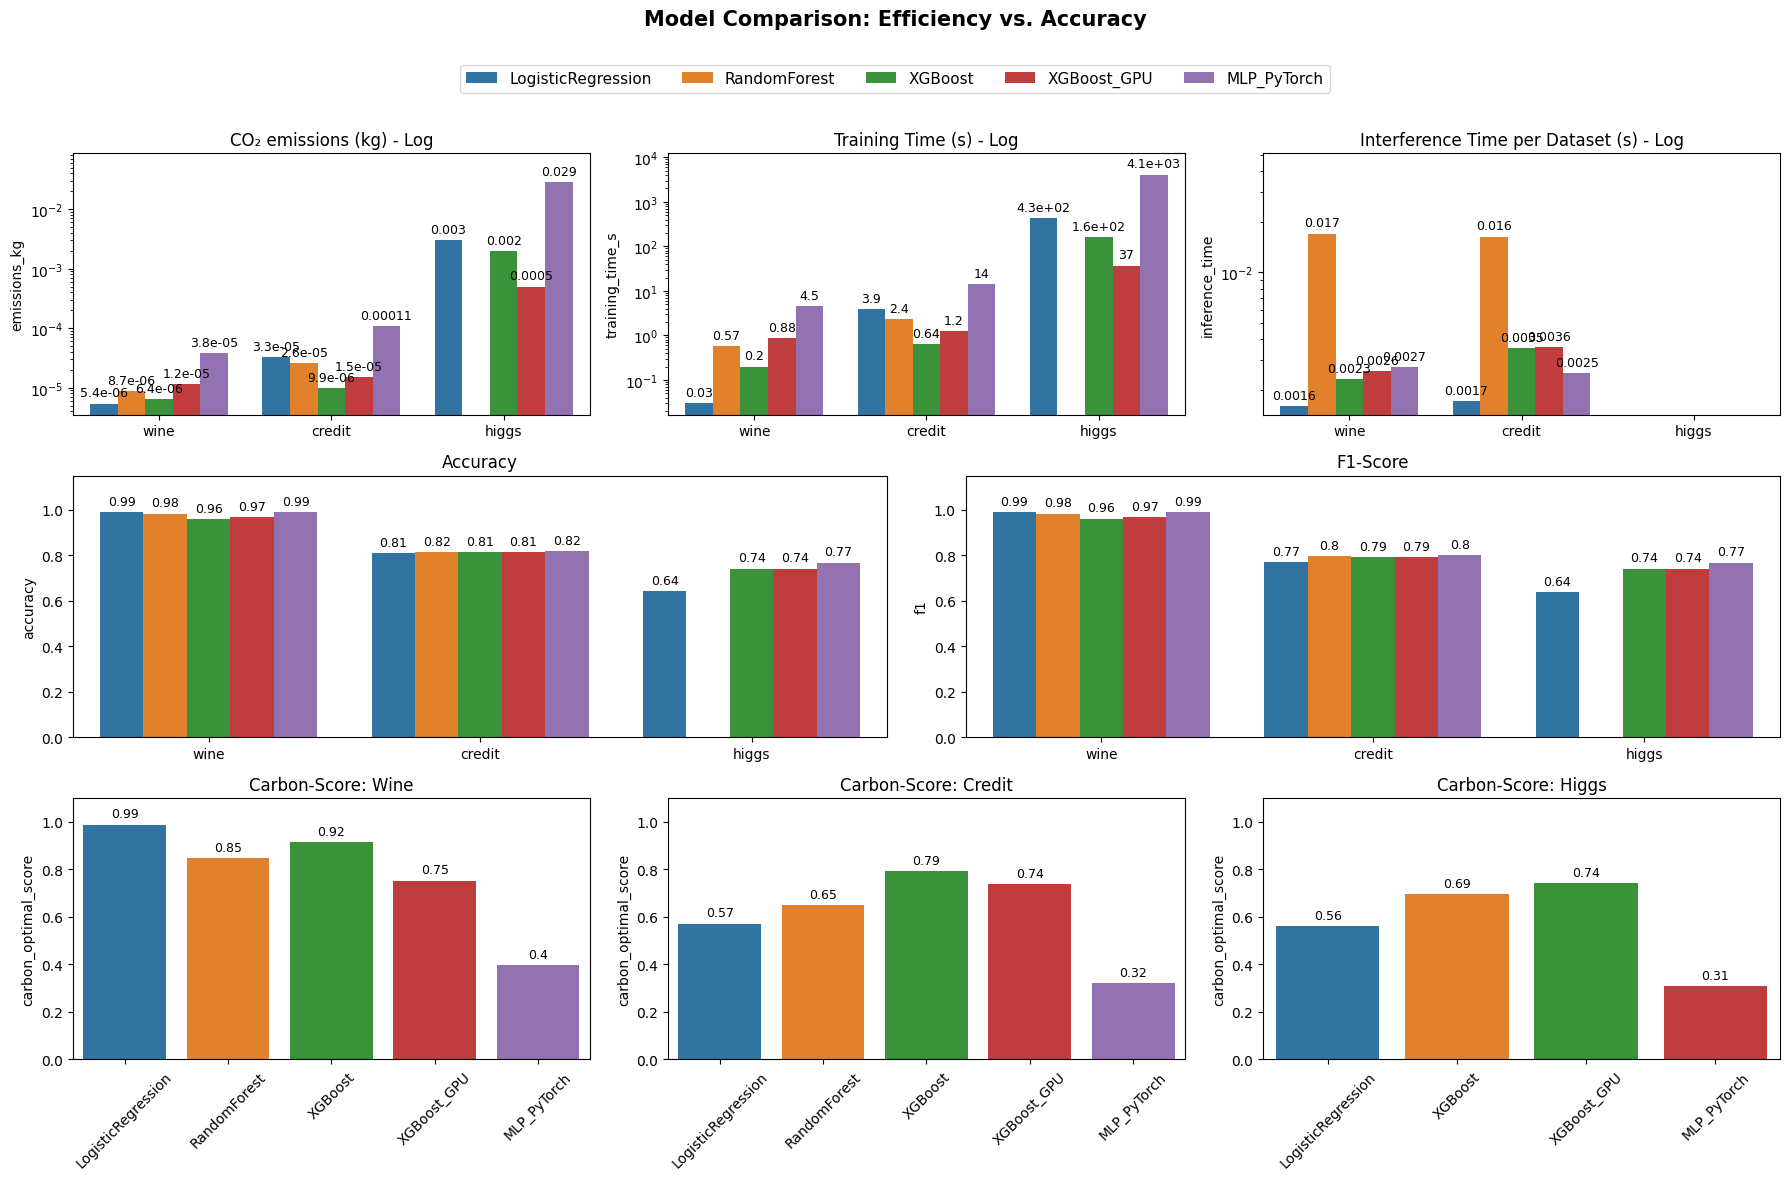

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Beide CSV-Dateien einlesen
df_results = pd.read_csv("../results/results.csv")
df_inf = pd.read_csv("../results/inference_time.csv")

df_results = df_results[["timestamp", "model", "dataset", "nrows", "accuracy", "f1", "emissions_kg", "training_time_s"]]

# Duplikate in beiden DataFrames bereinigen
df_results = df_results.drop_duplicates(subset=["dataset", "nrows", "model"], keep="last")
df_inf = df_inf.drop_duplicates(subset=["dataset", "nrows", "model"], keep="last")

# 2. DataFrames anhand von Modell, Datensatz und Zeilenanzahl zusammenführen (Merge)
df = pd.merge(df_results, df_inf[["model", "dataset", "nrows", "inference_time"]], on=["model", "dataset", "nrows"], how="left")

# l_1 gibt der Trainingszeit etwas weniger Gewicht während l_2 die emissions mit voller Gewichtung betrachtet.
l_1 = 0.5
l_2 = 1

min_time = df.groupby('dataset')['training_time_s'].transform('min')
max_time = df.groupby('dataset')['training_time_s'].transform('max')
df['time_scaled'] = (df['training_time_s'] - min_time) / (max_time - min_time)

min_co2 = df.groupby('dataset')['emissions_kg'].transform('min')
max_co2 = df.groupby('dataset')['emissions_kg'].transform('max')
df['co2_scaled'] = (df['emissions_kg'] - min_co2) / (max_co2 - min_co2)

df["carbon_optimal_score"] = df["f1"] / (1 + l_1 * df["time_scaled"] + l_2 * df["co2_scaled"])

# 3. Layout anpassen: Erste Zeile hat nun 3 Plots (emissions, time, inf_time)
layout = [
    ["emissions", "emissions", "time", "time", "inf_time", "inf_time"],
    ["acc", "acc", "acc", "f1", "f1", "f1"],
    ["carb_wine", "carb_wine", "carb_credit", "carb_credit", "carb_higgs", "carb_higgs"]
]

fig, axes = plt.subplot_mosaic(layout, figsize=(18, 12)) # Breite leicht erhöht für 3 Plots nebeneinander
fig.suptitle("Model Comparison: Efficiency vs. Accuracy", fontsize=15, fontweight='bold', y=0.98)

# --- REIHE 1: Ressourcen & Zeit ---
sns.barplot(data=df, x="dataset", y="emissions_kg", hue="model", ax=axes["emissions"])
axes["emissions"].set_title("CO₂ Emissions (kg) - Log")
axes["emissions"].set_yscale("log")
axes["emissions"].set_xlabel("")
axes["emissions"].set_ylim(top=df["emissions_kg"].max() * 3)

sns.barplot(data=df, x="dataset", y="training_time_s", hue="model", ax=axes["time"])
axes["time"].set_title("Training Time (s) - Log")
axes["time"].set_yscale("log")
axes["time"].set_xlabel("")
axes["time"].set_ylim(top=df["training_time_s"].max() * 3)

# NEU: Inferenzzeit Plot
sns.barplot(data=df, x="dataset", y="inference_time", hue="model", ax=axes["inf_time"])
axes["inf_time"].set_title("Interference Time per Dataset (s) - Log")
axes["inf_time"].set_yscale("log")
axes["inf_time"].set_xlabel("")
axes["inf_time"].set_ylim(top=df["inference_time"].max() * 3)

# --- REIHE 2: Vorhersagegüte ---
sns.barplot(data=df, x="dataset", y="accuracy", hue="model", ax=axes["acc"])
axes["acc"].set_title("Accuracy")
axes["acc"].set_ylim(0, 1.15)
axes["acc"].set_xlabel("")

sns.barplot(data=df, x="dataset", y="f1", hue="model", ax=axes["f1"])
axes["f1"].set_title("F1-Score")
axes["f1"].set_ylim(0, 1.15)
axes["f1"].set_xlabel("")

# --- REIHE 3: Custom Score ---
datasets = ["wine", "credit", "higgs"]
carb_keys = ["carb_wine", "carb_credit", "carb_higgs"]

for ds, key in zip(datasets, carb_keys):
    subset = df[df["dataset"] == ds]
    sns.barplot(data=subset, x="model", y="carbon_optimal_score", hue="model", ax=axes[key], dodge=False)
    axes[key].set_title(f"Carbon-Score: {ds.capitalize()}")
    axes[key].set_xlabel("")
    axes[key].set_ylim(0, 1.1)
    axes[key].tick_params(axis='x', rotation=45)

# --- Labels und Legende ---
for name, ax in axes.items():
    for container in ax.containers:
        # fmt="%.2g" formatiert extrem kleine Zahlen (wie Inferenzzeiten) automatisch in wissenschaftliche Notation (z.B. 1.2e-05)
        ax.bar_label(container, fmt="%.2g", padding=3, fontsize=9) 
    
    if ax.get_legend():
        ax.get_legend().remove()

handles, labels = axes["emissions"].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=5, fontsize=11, title=None)

plt.tight_layout(rect=[0, 0, 1, 0.92]) 
plt.savefig("../results/vergleich.png", dpi=150, bbox_inches="tight")
plt.show()